# Jupyter Notebook
# CMSE381 - Lec 31 - CNNs


<img src="https://upload.wikimedia.org/wikipedia/commons/6/63/Typical_cnn.png" alt="Simple Convlutional Neural Net" width="600"/>

In [1]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import time

## Playing with CNNs

Our next job is to get some more intuition for the Convolutional Neural Net architecture. 

Load in the toy "image" [on the DataSets page](../../DataSets/DataSets.md#dl-toyimage) to try out some tools. 

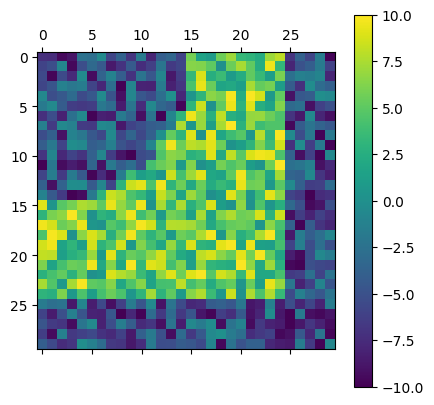

In [2]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/9df4c0ec6c692c4bfec98dd22cc76350/DL-ToyImage.csv"
M = np.loadtxt(url)
plt.matshow(M)
plt.colorbar()
plt.show()

### Convolution Layer 

First, we're going to try out convlution on this image. Here's a convolution filter matrix for us to test this onn.

[[1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1.]]


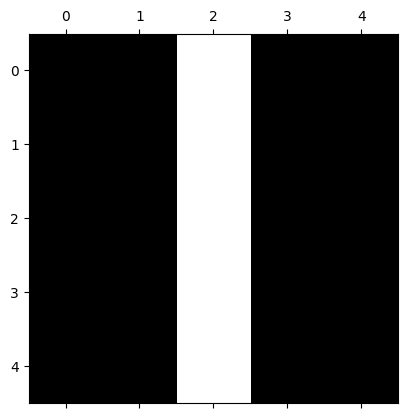

In [3]:
F = np.zeros((5,5))
F[:,:2] = 1
F[:, 3:] = 1
plt.spy(F)
print(F)
plt.show()

&#9989; **<font color=red>Do this:</font>** Extract a portion of the matrix $M$ from the top left of the same size as the filter matrix $F$ and take the dot product of the two. This is the entry that would go in entry $[0, 0]$ of the convolved image.

In [5]:
# Your code here

patch = M[:5, :5]
value = np.sum(patch * F)
print(value)

-104.00000000000001


&#9989; **<font color=red>Do this:</font>** Do the same thing, but shifted right by one. This is the entry that would go in entry $[0, 1]$ of the convolved image. 

In [6]:
# Your code here

patch = M[:5, 1:6]
value = np.sum(patch * F)
print(value)

-94.4


&#9989; **<font color=red>Do this:</font>** Now, do this for every entry in the matrix. Update this `NewM` matrix so that each entry is the convolution of the input image. 

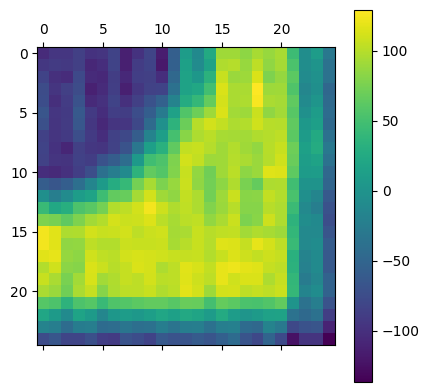

In [7]:
NewM = np.zeros((30-F.shape[0], 30-F.shape[0]))

for i in range(NewM.shape[0]):
    for j in range(NewM.shape[1]):
        patch = M[i:i+F.shape[0], j:j+F.shape[1]]
        NewM[i, j] = np.sum(patch * F)

plt.matshow(NewM)
plt.colorbar()
plt.show()

&#9989; **<font color=red>Do this:</font>** Here's a different filter. What happens when you convolve the image with this one instead? 

[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


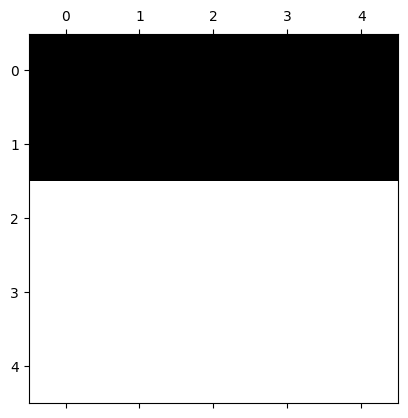

In [8]:
F = np.zeros((5,5))
F[:2,:] = 1
print(F)
plt.spy(F)
plt.show()

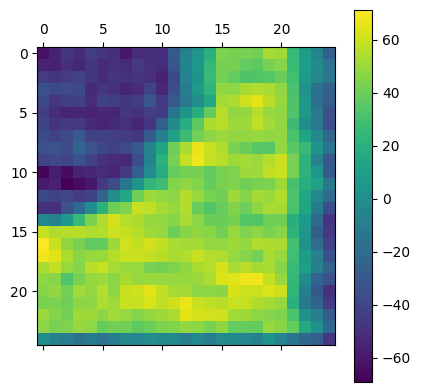

In [10]:
# Your code here

F = np.zeros((5,5))
F[:2, :] = 1

NewM = np.zeros((30 - F.shape[0], 30 - F.shape[1]))

for i in range(NewM.shape[0]):
    for j in range(NewM.shape[1]):
        patch = M[i:i+F.shape[0], j:j+F.shape[1]]
        NewM[i, j] = np.sum(patch * F)

plt.matshow(NewM)
plt.colorbar()
plt.show()

# It acts like a horizontal feature detector
# Highlights areas where:
# The upper part of a region is bright
# Compared to what comes below
# Strong responses along horizontal edges
# Especially where intensity changes from top → bottom

### Pooling Layer

After our convolution layer, we often build a pooling layer. 

&#9989; **<font color=red>Do this:</font>** Fix up the following code to create a pooled image from your convolved image.

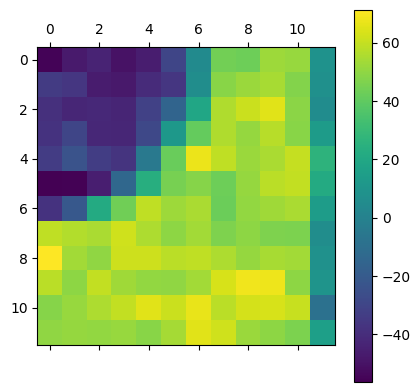

In [11]:
poolM = np.zeros((NewM.shape[0]//2, NewM.shape[1]//2))

for i in range(NewM.shape[0]//2):
    for j in range(NewM.shape[1]//2):
        patch = NewM[2*i:2*i+2, 2*j:2*j+2]
        poolM[i, j] = np.max(patch)

plt.matshow(poolM)
plt.colorbar()
plt.show()

## Playing with a pre-trained classifier
As with the regular neural nets, trying to train our own CNN is beyond the scope of the class. But we can play with some toys to see how the trained versions work. 

Open the following in another browser tab to answer the questions below: https://poloclub.github.io/cnn-explainer/


&#9989; **<font color=red>Q:</font>** 
1. Read the section below on what each layer of the network does. 
1. What is the 2nd top prediction output for the bell pepper picture?
1. Clicking on the "+" button lets you upload a picture.  What does your face get classified as?



-----
### Congratulations, we're done!
Initially created by Dr. Liz Munch, modified by Dr. Lianzhang Bao and Dr. Firas Khasawneh, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.